In [1]:
import inspect

import matplotlib.pyplot as plt
import pandas as pd

import strategies
from run_tournament import simulate_game, simulate_tournament
from strategies import (
    StratBeatsLast,
    Strategy,
    StratPatternBeater,
    StratPatternmatcher1dV1,
)

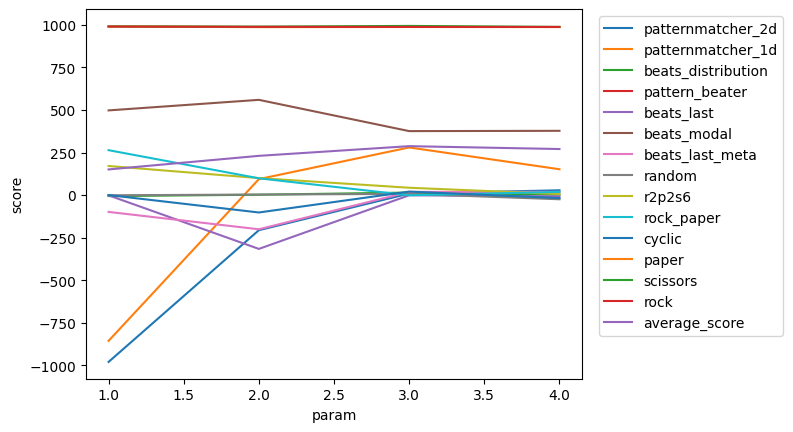

In [2]:
# view hyperparam performace against all strategies

scores: list[pd.Series[int]] = []
strategy_list: list[Strategy] = [
    obj()
    for name, obj in vars(strategies).items()
    if inspect.isclass(obj)
    and not inspect.isabstract(obj)
    and issubclass(obj, Strategy)
    and name != "StratPatternBeater"
]


for i in range(1, 5):
    strategy: Strategy = StratPatternBeater(pattern_length=i)
    score_df, _ = simulate_tournament(3, 1000, {*strategy_list, strategy})

    row = score_df.loc[strategy.name]
    assert isinstance(row, pd.Series)
    scores.append(row)


results = pd.DataFrame(scores, index=range(1, 5))
results.index.name = "param"
ax = results.plot()
_ = ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
_ = plt.ylabel("score")
plt.show()

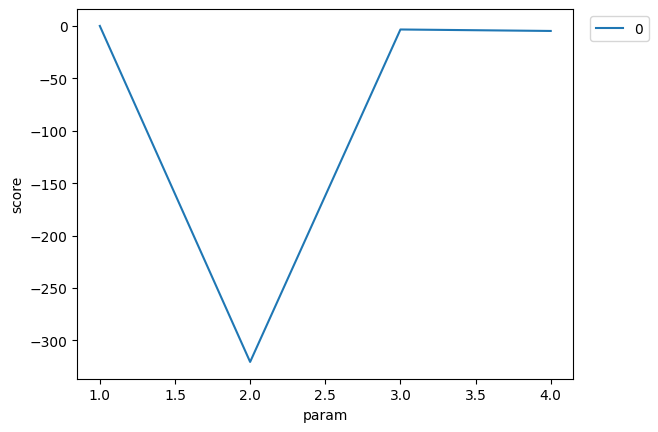

In [3]:
# view hyperparam performace against specific strat

scores: list[float] = []
for i in range(1, 5):
    strategy_1: Strategy = StratPatternBeater(i)
    strategy_2: Strategy = StratBeatsLast()

    score_df, _ = simulate_tournament(10, 1000, {strategy_1, strategy_2})

    score = score_df.loc[strategy.name].iloc[0]
    assert isinstance(score, float)
    scores.append(score)

results = pd.DataFrame(scores, index=range(1, 5))
results.index.name = "param"
ax = results.plot()
_ = ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
_ = plt.ylabel("score")
plt.show()

pattern_beater      : SSSPRRSRRSPPRSPRSRSPRPPRSRPPSSSRPRPRRPPPPSSPSPRPRRPRSSSRRRPRSSSSSSSPPSPSRPRPSSPPPPSPPPPRRRRRRRSRPSPPRPSPRRRSSSPRRRSSSPRSPSRRPSRRPSSRRRSSPSSRSRRRPSSRSRRSPSSSPSPRSPPRPPPPRPPRPRPRRSPPSPSSSRPSPPPPRRRPPRRRPPSRRRPPSRSSPPRRRRRSPRSSSRPPPSRSSSRRSRSSSRRSRSSSSSPSSPPPPRRSRPPPRSPRPSSPPPRSRPRRSSSPRPSPRPPRSRRPRSSPRRSSPRRSSPSPSPSPPPPRPRRRSPSRSPSSRSPPPRPRRRPRSSSRSPPRRSPRRSSPSPPSRPRSPSSRPPPSSSRPPPSSSSSPPRRPRSPPRSRRPPPSPRSRRRRRRSPRSRRSPRPSSSPPPSPRPRRRSRSPSSPRRSRSRSSSRRPRSSSRRPSPSPPPSRPRPPPPPRRRSRSPSSSSSPRRPSPRPPPRSRPRPSRRRPSSSPSPPPSRSRPSPPPSSPSPRRRPPRSRRRRSRSRRSSSRSRSPPPPPRRRPPSSPPRSRRRPRSSSRSRSSSSSPPRPSRPPPRPPRPPRRRPRSSSPRSSSRPRPRSSSRPPRSPPSPRSPRSPRPRPRRRRRSSSSSPRPSSSPSPPPSPRRPSPSPPPSRPRRRSPSRRRPSRRRPPSRSRPSSSRRSPSSSRRPPRPSPSSPSPPPPPRRRRRSRPSRSSPPRSPRRRSRSSSSSPPRPSRPPPRPRRRPRSSSPRSPSSSRSPPPSSPRPPPSSPSRPPPPPRRRPRPSRRRRRSSPSRRRSSPPRRRPSSPPRSRRRPSSSRSPPSPRRRRRSPSSSSSPRSPSSPRPPPRSRPRPPSPRRRSPSSPSPSRRRPPSRSRRSRSSSPSPPPSRSPPPSSPPPPPRRRPPRSRRRRRSRSRRSSSRPRPSSSRPSPSSPPPRPRRRSSSSSPRSPPPSSPR

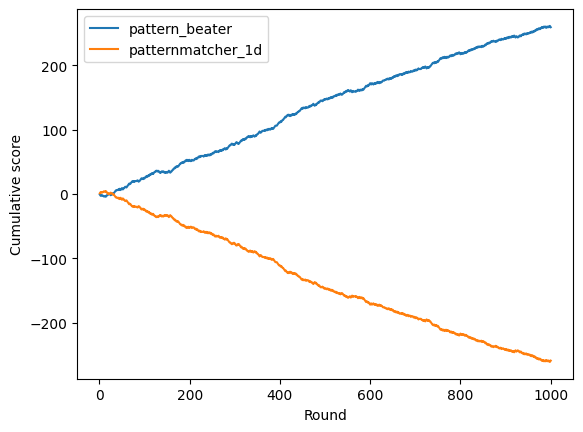

In [4]:
# look at detailed game for a single strat

_ = simulate_game(
    1000, StratPatternBeater(3), StratPatternmatcher1dV1(), verbose=True, plot=True
)